In [25]:
import numpy as np
import sklearn
from sklearn import datasets
import matplotlib.pyplot as plt

In [26]:
bb = datasets.load_breast_cancer()
X = bb.data
y = bb.target

In [27]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)


In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xtrain, ytrain)
ypredtest = knn.predict(Xtest)

[[30  4]
 [ 3 77]]


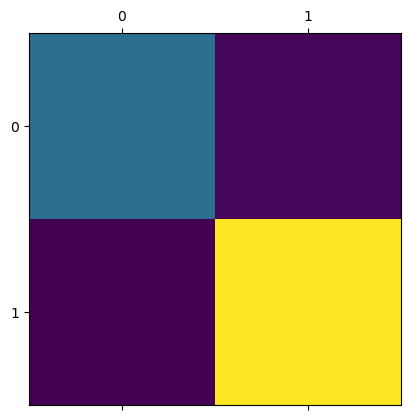

In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, ypredtest)
plt.matshow(cm)
print(cm)

In [39]:
def accuracy(ytest, ypredtest):
    cm = confusion_matrix(ytest, ypredtest)
    accuracy = np.diag(cm).sum()/cm.sum()
    return accuracy

In [44]:
def precesion (ytest, ypredtest):
    prec = []
    cm = confusion_matrix(ytest, ypredtest)
    for i, col in enumerate(cm.T):
        preci = col[i]/col.sum()
        prec.append(preci)
    return np.mean(prec)        


In [58]:
def recall(ytrain, ypredtest):
    recall = []
    cm = confusion_matrix(ytrain, ypredtest)
    for i, row in enumerate(cm):
        reci = row[i]/row.sum()
        recall.append(reci)
    return np.mean(recall)   

In [59]:
from sklearn.metrics import precision_score, recall_score, accuracy_score
accuracy(ytest, ypredtest) == accuracy_score(ytest, ypredtest)

True

In [60]:
precesion(ytest, ypredtest) == precision_score(ytest, ypredtest, average='macro')

True

In [61]:
recall(ytest, ypredtest) == recall_score(ytest, ypredtest, average='macro')

True

In [80]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
X = data.data
y = data.target

In [81]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [82]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)

In [99]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(Xtrain, ytrain)

ypred = reg.predict(Xtest)

print(Xtrain.shape)
print(Xtest.shape)

(16512, 8)
(4128, 8)


In [100]:
print(reg.coef_)

[ 4.38800071e-01  9.68029755e-03 -1.11393482e-01  6.65869611e-01
 -2.66670361e-06 -3.45731900e-03 -4.18656399e-01 -4.31242492e-01]


In [101]:
print(reg.intercept_)

-36.66261766130286


In [102]:
print(ypred[:5])

[1.99750996 3.65138176 0.91897459 2.83656325 1.18157842]


In [103]:
print(ytest[:5])

[2.056 5.    1.464 3.336 0.938]


In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE: ", mean_absolute_error(ytest, ypred))
print("MSE: ", mean_squared_error(ytest, ypred))
print("R2: ", r2_score(ytest, ypred))


MAE:  0.5310954405051491
MSE:  0.5181141109009567
R2:  0.6049447479475182


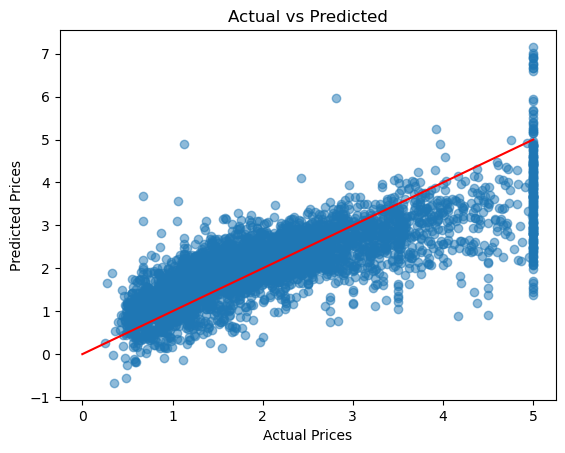

In [117]:
plt.scatter(ytest, ypred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")#
plt.plot([0, 5], [0, 5], 'r')


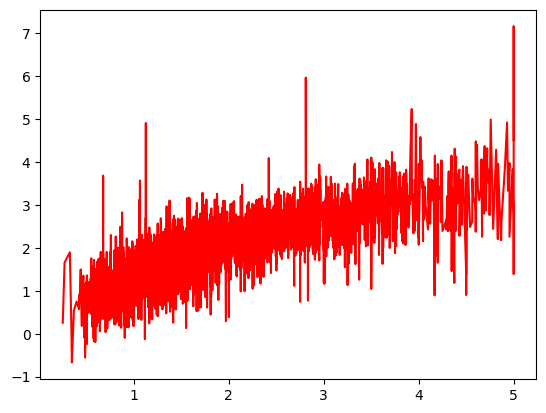

In [120]:
import numpy as np
sorted_idx = np.argsort(ytest)
plt.plot(ytest[sorted_idx], ypred[sorted_idx], 'r')